# LangGraph 실험

In [1]:
from typing import TypedDict
from helper_dev_utils import *
from langgraph.graph import StateGraph, START, END

helper_help(StateGraph)


Signature : StateGraph(state_schema: 'type[StateT]', context_schema: 'type[ContextT] | None' = None, *, input_schema: 'type[InputT] | None' = None, output_schema: 'type[OutputT] | None' = None, **kwargs: 'Unpack[DeprecatedKwargs]') -> 'None'
Docstring :
A graph whose nodes communicate by reading and writing to a shared state.

The signature of each node is `State -> Partial<State>`.

Each state key can optionally be annotated with a reducer function that
will be used to aggregate the values of that key received from multiple nodes.
The signature of a reducer function is `(Value, Value) -> Value`.

!!! warning

    `StateGraph` is a builder class and cannot be used directly for execution.
    You must first call `.compile()` to create an executable graph that supports
    methods like `invoke()`, `stream()`, `astream()`, and `ainvoke()`. See the
    `CompiledStateGraph` documentation for more details.

Args:
    state_schema: The schema class that defines the state.
    context_schema: 

In [2]:
import logging
helper_help(logging)
print("=" * 80)
helper_help(logging.basicConfig)

Signature : logging
Docstring :
Logging package for Python. Based on PEP 282 and comments thereto in
comp.lang.python.

Copyright (C) 2001-2019 Vinay Sajip. All Rights Reserved.

To use, simply 'import logging' and log away!
Signature : basicConfig(**kwargs)
Docstring :
Do basic configuration for the logging system.

This function does nothing if the root logger already has handlers
configured, unless the keyword argument *force* is set to ``True``.
It is a convenience method intended for use by simple scripts
to do one-shot configuration of the logging package.

The default behaviour is to create a StreamHandler which writes to
sys.stderr, set a formatter using the BASIC_FORMAT format string, and
add the handler to the root logger.

A number of optional keyword arguments may be specified, which can alter
the default behaviour.

filename  Specifies that a FileHandler be created, using the specified
          filename, rather than a StreamHandler.
filemode  Specifies the mode to open th

26-07-09 18:38:09 [D] 테스트 로그 시작


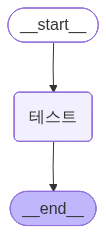

In [3]:
import logging
import time
from datetime import datetime
from zoneinfo import ZoneInfo
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

#logging.Formatter.converter = time.localtime
#logging.Formatter.converter = lambda *args: datetime.now(tz=ZoneInfo("Asia/Seoul")).timetuple()
#logging.basicConfig(level=logging.DEBUG, format="%(asctime)s [%(levelname)s] %(message)s")
#log = logging.getLogger(__name__)
#logging.root.handlers = []

class  LogFormatter(logging.Formatter):
    # LEVEL_ABBREV = {
    #     'DEBUG': 'D',
    #     'INFO': 'I',
    #     'WARNING': 'W',
    #     'ERROR': 'E',
    #     'CRITICAL': 'C',
    # }
    
    def formatTime(self, record, datefmt=None):
        dt = datetime.fromtimestamp(record.created, tz=ZoneInfo("Asia/Seoul"))
        if datefmt:
            return dt.strftime(datefmt)
        return dt.isoformat()
    
    # def format(self, record):
    #     record.levelname = self.LEVEL_ABBREV.get(record.levelname, record.levelname[0])
    #     return super().format(record)

formatter = LogFormatter(fmt="%(asctime)s [%(levelname).1s] %(message)s", datefmt="%y-%m-%d %H:%M:%S")
handler = logging.StreamHandler()
handler.setFormatter(formatter)
log = logging.getLogger(__name__)
log.setLevel(logging.DEBUG)
log.handlers = []
log.addHandler(handler)
log.propagate = False

log.debug("테스트 로그 시작")

class MyState(TypedDict):
    x : int
    y : int
    z : int
    
def node_partial(state: MyState) -> dict:
    """x, y 만 업데이트하고 z는 그대로 두는 테스트"""
    log.debug(f"node_partial: state={state}")
    return {"x": state["x"] + 1, "y": state["y"] + 1, "z": state["z"]}
    
g1 = StateGraph(state_schema=MyState, start_state=START, end_state=END)

g1.add_node("테스트", node_partial)
g1.add_edge(START, "테스트")
g1.add_edge("테스트", END)

a1 = g1.compile()

from IPython.display import display, Image, HTML
display(Image(a1.get_graph().draw_mermaid_png()))

# r1 = a1.invoke({"x": 1, "y": 2, "z": 3})
# log.debug(f"r1={r1}")


In [ ]:
r1 = a1.invoke({"x": 1, "y": 2, "z": 3})
log.debug(f"r1={r1}")


In [ ]:
class ExpState(TypedDict):
    x : int
    y : int
    z : int
    
def node_empty(state: ExpState) -> dict:
    return {}
    
g2 = StateGraph(state_schema=ExpState, start_state=START, end_state=END)

g2.add_node("원본", node_empty)
g2.add_edge(START, "원본")
g2.add_edge("원본", END)

a2 = g2.compile()

from IPython.display import display, Image, HTML
display(Image(a2.get_graph().draw_mermaid_png()))


In [ ]:
from typing import Annotated, TypedDict
import operator

class NoReducerState(TypedDict):
    text : str
    logs: list
    
class WithReducerState(TypedDict):
    text : str
    logs: Annotated[list, operator.add]

def node_a(state) -> dict:
    return {"logs": ["A 완료"]}

def node_b(state) -> dict:
    return {"logs": ["B 완료"]}




In [ ]:
class NoReducerState(TypedDict):
    text : str
    logs: list

def node_a(state) -> dict:
    return {"logs": ["A 완료"]}

def node_b(state) -> dict:
    return {"logs": ["B 완료"]}

g_no = StateGraph(state_schema=NoReducerState)
g_no.add_node("A", node_a)
g_no.add_node("B", node_b)
g_no.add_edge(START, "A")
g_no.add_edge(START, "B")
g_no.add_edge("A", END)
g_no.add_edge("B", END)
ag_no = g_no.compile()

display(Image(ag_no.get_graph().draw_mermaid_png()))

try:
    r_no = ag_no.invoke({"text": "테스트", "logs": []})
    log.debug(f"r_no={r_no}")
except Exception as e:
    log.error(f"Error occurred: {e}")

In [ ]:
class WithReducerState(TypedDict):
    text : str
    logs: Annotated[list, operator.add]

def node_a(state) -> dict:
    return {"logs": ["A 완료"]}

def node_b(state) -> dict:
    return {"logs": ["B 완료"]}

def node_aa(state) -> dict:
    return {"logs": ["AA 완료"]}

g_with = StateGraph(state_schema=WithReducerState)
g_with.add_node("A", node_a)
g_with.add_node("B", node_b)
g_with.add_node("AA", node_aa)
g_with.add_edge(START, "A")
g_with.add_edge(START, "B")
g_with.add_edge("A", "AA")
g_with.add_edge("A", END)
g_with.add_edge("B", END)

log.debug(f"g_with={g_with}")

ag_with = g_with.compile()

log.debug(f"ag_with={ag_with}")

display(Image(ag_with.get_graph().draw_mermaid_png()))

rag = ag_with.invoke({"text": "테스트", "logs": []})
log.debug(f"rag={rag}")

# logs를 초기화 하려면?
rag["logs"] = []

rag = ag_with.invoke(rag)
log.debug(f"rag={rag}")


In [ ]:
class ExitState(TypedDict):
    text : str
    logs: Annotated[list, operator.add]

def node_start(state) -> dict:
    return {"logs": ["시작"]}

def node_a(state) -> dict:
    return {"logs": ["A 진행"]}

def node_b(state) -> dict:
    return {"logs": ["B 진행"]}

def node_end(state) -> dict:
    return {"logs": ["종료"]}


s = StateGraph(state_schema=ExitState)
s.add_node("START", node_start)
s.add_node("A", node_a)
s.add_node("B", node_b)
s.add_node("END", node_end)
s.add_edge(START, "START")
s.add_edge("START", "A")
s.add_edge("START", "B")
s.add_edge("A", "END")
s.add_edge("B", "END")
s.add_edge("END", END)

log.debug(f"s={s}")

as_ = s.compile()

display(Image(as_.get_graph().draw_mermaid_png()))

rag = as_.invoke({"text": "A", "logs": []})
log.debug(f"rag={rag}")


In [ ]:
class CondState(TypedDict):
    text: str
    logs: Annotated[list, operator.add]

def node_start(state) -> dict:
    return {"logs": [f"시작: {state['text']}"]}

def node_a(state) -> dict:
    return {"logs": ["A 경로 실행"]}

def node_b(state) -> dict:
    return {"logs": ["B 경로 실행"]}

def route_choice(state) -> str:
    """text 값에 따라 "A" 또는 "B" 반환"""
    if state["text"] == "A":
        return "A"
    else:
        return "B"

cond = StateGraph(state_schema=CondState)
cond.add_node("START", node_start)
cond.add_node("A", node_a)
cond.add_node("B", node_b)

cond.add_edge(START, "START")
# ← 여기서 조건부 라우팅: START 노드 후 route_choice 함수에 따라 A 또는 B로 분기
cond.add_conditional_edges("START", route_choice, {"A": "A", "B": "B"})
cond.add_edge("A", END)
cond.add_edge("B", END)

acond = cond.compile()

display(Image(acond.get_graph().draw_mermaid_png()))

# text="A"이면 A 경로로
r_a = acond.invoke({"text": "A", "logs": []})
log.debug(f"text='A': {r_a}")

# text="X"이면 B 경로로 (else 분기)
r_b = acond.invoke({"text": "X", "logs": []})
log.debug(f"text='X': {r_b}")

In [ ]:
class CondState(TypedDict):
    text: str
    logs: Annotated[list, operator.add]

def node_start(state) -> dict:
    return {"logs": [f"시작: {state['text']}"]}

def node_a(state) -> dict:
    return {"logs": ["A 경로 실행"]}

def node_b(state) -> dict:
    return {"logs": ["B 경로 실행"]}

def node_c(state) -> dict:
    return {"logs": ["C 경로 실행"]}

def route_choice(state) -> str:
    """text 값에 따라 "A" 또는 "B" 반환"""
    if state["text"] == "A":
        return "A"
    elif state["text"] == "B":
        return "B"
    else:
        return "C"

cond = StateGraph(state_schema=CondState)
cond.add_node("START", node_start)
cond.add_node("A1", node_a)
cond.add_node("B1", node_b)
cond.add_node("C1", node_c)

cond.add_edge(START, "START")
# ← 여기서 조건부 라우팅: START 노드 후 route_choice 함수에 따라 A 또는 B로 분기
cond.add_conditional_edges("START", route_choice, {"A": "A1", "B": "B1", "C": "C1"})
cond.add_edge("A1", END)
cond.add_edge("B1", END)
cond.add_edge("C1", END)

acond = cond.compile()

display(Image(acond.get_graph().draw_mermaid_png()))

# text="A"이면 A 경로로
r_a = acond.invoke({"text": "A", "logs": []})
log.debug(f"text='A': {r_a}")

# text="X"이면 B 경로로 (else 분기)
r_b = acond.invoke({"text": "X", "logs": []})
log.debug(f"text='X': {r_b}")

In [ ]:
import os, json, re
from dotenv import load_dotenv

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")
model = "gemini-3.1-flash-lite-preview"

log.debug(f"api_key={api_key[:10]}... model={model}")

llm = ChatGoogleGenerativeAI(model=model, google_api_key=api_key, temperature=0)

class DemoState(TypedDict):
    topic: str
    summary: list
    word_count: int
    processed: bool
    
summary_prompt = ChatPromptTemplate.from_messages([
    ("system", "주어진 주제를 정확히 한 문장으로 설명해."),
    ("human", "{topic}"),
])

parser = StrOutputParser()
async def summarize_node(state: DemoState) -> dict:
    summary = await (summary_prompt | llm | parser).ainvoke({"topic": state["topic"]})
    word_count = len(summary)
    return ({"summary": [summary], "word_count": word_count})

async def make_processed_node(state: DemoState) -> dict:
    log.debug(f"[make-processed] summary 길이: {state['word_count']}자")
    return {"processed" : True}

s = StateGraph(state_schema=DemoState)
s.add_node("질의", summarize_node)
s.add_node("mark", make_processed_node)
s.add_edge(START, "질의")
s.add_edge("질의", "mark")
s.add_edge("mark", END)
as_ = s.compile()

display(Image(as_.get_graph().draw_mermaid_png()))



In [ ]:
result = await as_.ainvoke({
    "topic": "머신러닝",
    "summary": [],
    "word_count": 0,
    "processed": False
})

log.debug(f"result={result}")
log.debug(f"topic={result['topic']}")
log.debug(f"summary={result['summary']}")
log.debug(f"word_count={result['word_count']}")
log.debug(f"processed={result['processed']}")

In [ ]:
class CapState(TypedDict):
    country: str
    capital: str
    
capital_prompt = ChatPromptTemplate.from_messages({
    ("system", "너는 지리 전문가야. 국가명을 받으면 수도 이름만 한단어로 대답해야 해. 영문명(한국어발음)"),
    ("human", "{country}의 수도는?")
})

async def capital_node(state: CapState) -> dict:
    capital = await (capital_prompt | llm | parser).ainvoke({"country": state["country"]})
    return {"capital": capital}

g = StateGraph(CapState)
g.add_node("find_capital", capital_node)
g.add_edge(START, "find_capital")
g.add_edge("find_capital", END)
ap = g.compile()

display(Image(ap.get_graph().draw_mermaid_png()))

result = await ap.ainvoke({"country": "대한민국", "capital": ""})
log.debug(f"result={result}")
log.debug(f"국가: {result['country']}, 수도: {result['capital']}")


In [ ]:

result = await ap.ainvoke({"country": "미국", "capital": ""})
log.debug(f"result={result}")
log.debug(f"국가: {result['country']}, 수도: {result['capital']}")


In [ ]:
async for chunk in ap.astream({"country": "프랑스", "capital": ""}):
    node_name = list(chunk.keys())[0]
    log.debug(f"chunk={chunk}")
    log.debug(f"node_name={node_name}")
    log.debug(f"  [{node_name}] 완료 - 변경사항 : {chunk[node_name]}")


In [ ]:
async for chunk in ap.astream({"country": "남아프리카공하국", "capital": ""}, stream_mode="messages"):
    msg, meta = chunk
    print(msg.content, end="", flush=True)
    # log.debug(f"msg={msg}, meta={meta}")


In [ ]:
from langchain_core.output_parsers import JsonOutputParser

json_prompt = ChatPromptTemplate.from_messages([
    ("system", "JSON만 출력해. 설명없이."),
    ("human", "{country}의 정보를 JSON으로, 키:name, captal, continent")
])

lcel_chain = json_prompt | llm | JsonOutputParser()
lcel_result = lcel_chain.invoke({"country": "브라질"})

log.debug(f"lcel_result={lcel_result}")
log.debug(f"lcel_result type={type(lcel_result)}")
log.debug(f"국가: {lcel_result['name']}, 수도: {lcel_result['capital']}, 대륙: {lcel_result['continent']}")


In [ ]:
class CountryState(TypedDict):
    country: str
    info: dict

async def country_info_node(state: CountryState) -> dict:
    info = await (json_prompt | llm | JsonOutputParser()).ainvoke({"country": state["country"]})
    return {"info": info}

s = StateGraph(CountryState)
s.add_node("info", country_info_node)
s.add_edge(START, "info")
s.add_edge("info", END)
ap = s.compile()

result = await ap.ainvoke({"country": "브라질", "info": {}})
log.debug(f"result={result}")
log.debug(f"국가: {result['country']}, 수도: {result['info']['name']} -> {result['info']['capital']}, 대륙: {result['info']['continent']}")

In [ ]:
class BlogState(TypedDict):
    text : str
    keywords : str
    blog : str
    
kw_prompt = ChatPromptTemplate.from_messages([
    ("system", "택스트에서 핵심 키워드 3개를 쉼표로 구분하여 추출해, 키워드만 출력."),
    ("human", "{text}")
])

parser = StrOutputParser()

kw_chain = kw_prompt | llm | parser
     
blog_prompt = ChatPromptTemplate.from_messages([
    ("system", "테크 블로그 작가야."),
    ("human", "키워드 {keywords}로 소개 문단 80자 이내로 작성해.")
])
blog_chain = blog_prompt | llm | parser

async def kw_node(state: BlogState) -> dict:
    kw = await kw_chain.ainvoke({"text": state["text"]})
    log.debug(f"[kw_node] text={state['text']}, keywords={kw}")
    return {"keywords": kw}

async def blog_node(state: BlogState) -> dict:
    blog = await blog_chain.ainvoke({"keywords": state["keywords"]})
    log.debug(f"[blog_node] keywords={state['keywords']}, blog={blog}")
    return {"blog": blog}

s = StateGraph(BlogState)
s.add_node("키워드", kw_node)
s.add_node("블로그", blog_node)
s.add_edge(START, "키워드")
s.add_edge("키워드", "블로그")
s.add_edge("블로그", END)
ap = s.compile()

display(Image(ap.get_graph().draw_mermaid_png()))
    

In [ ]:
text = "딥러닝 인공지능신경망을 여러 층으로 쌓아 복잡한 패턴을 학습하는 기술이다."
result = await ap.ainvoke({"text": text, "keywords": "", "blog": ""})
log.debug(f"result={result}")
log.debug(f"텍스트: {result['text']}")
log.debug(f"키워드: {result['keywords']}")
log.debug(f"블로그: {result['blog']}")

In [ ]:
class ReportState(TypedDict):
    text: str
    summary: str
    keywords: str
    report: str
    
summary_prompt = ChatPromptTemplate.from_messages([
    ("system", "주어진 텍스트를 정확히 한 문장으로 요약해."),
    ("human", "{text}")
])

report_prompt = ChatPromptTemplate.from_messages([
    ("system", "기술 보고서 작가야"),
    ("human", "요약: {summary}\n키워드: {keywords}\n- 100자 이내 보고서 작성"),
])

async def node_summary(state: ReportState) -> dict:
    summary = await (summary_prompt | llm | parser).ainvoke({"text": state["text"]})
    log.debug(f"[node_summary] text={state['text']}")
    log.debug(f"[node_summary] summary={summary}")
    return {"summary": summary}

async def node_keywords(state: ReportState) -> dict:
    keywords = await (kw_prompt | llm | parser).ainvoke({"text": state["text"]})
    log.debug(f"[node_keywords] text={state['text']}")
    log.debug(f"[node_keywords] keywords={keywords}")
    return {"keywords": keywords}

async def node_report(state: ReportState) -> dict:
    report = await (report_prompt | llm | parser).ainvoke({"summary": state["summary"], "keywords": state["keywords"]})
    log.debug(f"[node_report] summary={state['summary']}")
    log.debug(f"[node_report] keywords={state['keywords']}")
    log.debug(f"[node_report] report={report}")
    return {"report": report}

s = StateGraph(ReportState)
s.add_node("요약", node_summary)
s.add_node("키워드", node_keywords)
s.add_node("보고서", node_report)
s.add_edge(START, "요약")
s.add_edge(START, "키워드")
s.add_edge("요약", "보고서")
s.add_edge("키워드", "보고서")
s.add_edge("보고서", END)

ap = s.compile()
display(Image(ap.get_graph().draw_mermaid_png()))


In [ ]:
result = await ap.ainvoke({"text":text, "summary": "", "keywords": "", "report": ""})
log.debug(f"result={result}")
log.debug(f"텍스트: {result['text']}")
log.debug(f"요약: {result['summary']}")
log.debug(f"키워드: {result['keywords']}")
log.debug(f"보고서: {result['report']}")

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from typing import Annotated, TypedDict

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

class ChatState(TypedDict):
    messages: Annotated[list, add_messages]

llm = ChatGoogleGenerativeAI(model=model, google_api_key=api_key, temperature=0)
SYS_MSG = SystemMessage(content="너는 친절하고 기역력이 좋은 AI야. 이전 대화를 기역하고 참조해.")

async def node_chat(state: ChatState) -> dict:
    res = await llm.ainvoke([SYS_MSG] + state["messages"])
    print_dic_tree(res)
    print_dic_tree(res.content[0])
    #log.debug(f"    [node_chat] messages={state['messages']}")
    #log.debug(f"    [node_chat] res={res}")
    return {"messages": [res]}

s = StateGraph(ChatState)

s.add_node("대화", node_chat)
s.add_edge(START, "대화")
s.add_edge("대화", END)

memory = MemorySaver()
ap = s.compile(checkpointer = memory)
display(Image(ap.get_graph().draw_mermaid_png()))


In [ ]:
from helper_dev_utils import print_dic_tree
memory = MemorySaver()
ap = s.compile(checkpointer = memory)

async def chat(msg, thread_id="default"):
    config = {"configurable": {"thread_id": thread_id}}
    result = await ap.ainvoke({"messages": [HumanMessage(content=msg)]}, config=config)
    #print_dic_tree(result)
    #print_dic_tree(result["messages"][0].content)
    #print_dic_tree(result["messages"][1].content)
    resp = result["messages"][-1].content
    print_dic_tree(resp)
    #log.debug(f"    result1={result['messages'][-1]}")
    #log.debug(f"    result2={resp}")
    return {"msg":msg, "content": resp[0]['text']}

log.debug("[세션1] thread_id='user1'")
res = await chat(msg="안녕! 내이름은 철수야.", thread_id="user1")
log.debug(f">> res={res}")
log.debug(f">> msg={res['msg']}")
log.debug(f">> content={res['content']}")

res = await chat("서울사이버대학교에 다니고 있어.", thread_id="user1")
log.debug(f">> res={res}")
log.debug(f">> msg={res['msg']}")
log.debug(f">> content={res['content']}")

res = await chat("내 이름이 뭐라고 했지?", thread_id="user1")  # 기억!
log.debug(f">> res={res}")
log.debug(f">> msg={res['msg']}")
log.debug(f">> content={res['content']}")

print("[세션 2 — thread_id='user2' (독립된 대화)]")
res = await chat("파이썬 리스트 컴프리헨션 설명해줘.", thread_id="user2")
log.debug(f">> res={res}")
log.debug(f">> msg={res['msg']}")
log.debug(f">> content={res['content']}")

res = await chat("방금 말한 것 예시 코드로 보여줘.", thread_id="user2")
log.debug(f">> res={res}")
log.debug(f">> msg={res['msg']}")
log.debug(f">> content={res['content']}")


In [ ]:
from helper_dev_utils import print_dic_tree
print_dic_tree(memory.storage)

In [ ]:
print(list(memory.storage.keys()))

In [ ]:
for thread_id in memory.storage.keys():
    config = {"configurable": {"thread_id": thread_id}}
    state = ap.get_state(config) # thread_id별 state를 가져옴
    messages = state.values["messages"] # state의 messages만 가져옴
    print(f"\n[thread_id: {thread_id}] — {len(messages)}개 메시지")
    for msg in messages: # message별 type, content 출력
        print(f"  [{msg.type}] {msg.content}")

In [ ]:
from helper_dev_utils import print_dic_tree

class NumState(TypedDict):
    number: int
    result: str
    
def node_even(state: NumState) -> dict:
    return {"result": f"{state['number']}은 짝수입니다."}

def node_odd(state: NumState) -> dict:
    return {"result": f"{state['number']}은 홀수입니다."}

def node_router(state: NumState) -> str:
    """number 값이 짝수이면 'even', 홀수이면 'odd' 반환"""
    if state["number"] % 2 == 0:
        return "even"
    else:
        return "odd"

def node_check(state: NumState) -> dict:
    #print_dic_tree(state)
    return {}


s = StateGraph(state_schema=NumState)
s.add_node("분기", node_check)
s.add_node("짝수", node_even)
s.add_node("홀수", node_odd)

s.add_edge(START, "분기")
s.add_conditional_edges("분기", node_router, {"even": "짝수", "odd": "홀수"})
s.add_edge("짝수", END)
s.add_edge("홀수", END)

ap = s.compile()
display(Image(ap.get_graph().draw_mermaid_png()))



In [ ]:
# 난수 발생 배열 10개 1 ~9까지
import random
numbers = [random.randint(1, 9) for _ in range(10)]
for num in numbers:
    result = ap.invoke({"number": num, "result": ""})
    #print_dic_tree(result)
    log.debug(f"number={num}, result={result['result']}")

26-07-09 18:47:39 [D] api_key=AIzaSyDEis... model=gemini-3.1-flash-lite-preview


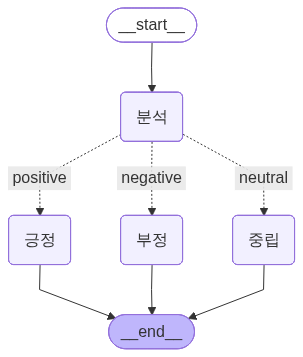

In [18]:
import os, json, re
from dotenv import load_dotenv

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

load_dotenv()

parser = StrOutputParser()
api_key = os.getenv("GEMINI_API_KEY")
model = "gemini-3.1-flash-lite-preview"

log.debug(f"api_key={api_key[:10]}... model={model}")

llm = ChatGoogleGenerativeAI(model=model, google_api_key=api_key, temperature=0)

class ReviewState(TypedDict):
    review: str
    sentiment: str
    response: str
    
analysis_prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 감정 분석 전문가야. 주어진 리뷰를 분석해서 다음 중 정확히 하나만 선택해: '긍정', '부정', '중립'. 선택한 감정 하나만 답변해."),
    ("human", "{review}")
])

async def node_analysis(state: ReviewState) -> dict: 
    sentiment = await (analysis_prompt | llm | parser).ainvoke({"review": state["review"]})
    sentiment = sentiment.strip()  # 공백 제거
    return {"sentiment": sentiment}

async def node_positive(state: ReviewState) -> dict:
    return {"response": "감사합니다! 좋은 경험을 하셨다니 정말 기쁩니다. 다음에도 잘 부탁드립니다"}

async def node_negative(state: ReviewState) -> dict:
    prompt = ChatPromptTemplate.from_messages([
        ("system", "고객 불만에 진심으로 사과하고 해결 의지를 표현해. 50자 이내."),
        ("human", "리뷰: {review}")
    ])
    result = await (prompt | llm | parser).ainvoke({"review": state["review"]})
    return {"response": "AI " + result}

async def node_neutral(state: ReviewState) -> dict:
    return {"response": "리뷰 감사합니다. 고객님의 의견을 소중히 여기겠습니다."}

def sentiment_router(state: ReviewState) -> str:
    """sentiment 값에서 첫 번째 감정 키워드만 추출해서 라우팅"""
    sentiment = state["sentiment"]
    # 정규식으로 첫 번째 감정 키워드 추출
    # if re.search(r"긍정|좋", sentiment):
    #     result = "positive"
    # elif re.search(r"부정|나쁨|나쁘", sentiment):
    #     result = "negative"
    # else:
    #     result = "neutral"

    # if re.search(r"긍정", sentiment):
    #     result = "positive"
    # elif re.search(r"부정", sentiment):
    #     result = "negative"
    # else:
    #     result = "neutral"

    if "긍정" in sentiment:
        result = "positive"
    elif "부정" in sentiment:
        result = "negative"
    else:
        result = "neutral"

    
    log.debug(f"[{result}] review={state['review']}")
    log.debug(f"[{result}] sentiment={state['sentiment']}")
    return result

s = StateGraph(ReviewState)
s.add_node("분석", node_analysis)
s.add_node("긍정", node_positive)
s.add_node("부정", node_negative)
s.add_node("중립", node_neutral)

s.add_edge(START, "분석")
s.add_conditional_edges("분석", sentiment_router, {"positive": "긍정", "negative": "부정", "neutral": "중립"})
s.add_edge("긍정", END)
s.add_edge("부정", END)
s.add_edge("중립", END)

ap = s.compile()
display(Image(ap.get_graph().draw_mermaid_png()))


In [19]:
test_reviews = [
    "배송도 빠르고 품질도 훌륭해요! 완전 만족합니다.",
    "포장이 엉망이고 제품도 불량이에요. 환불 원합니다.",
    "평범한 제품이에요. 딱 가격만큼이에요.",
]

print("=" * 80)

for review in test_reviews:
    result = await ap.ainvoke({"review": review, "sentiment": "", "response": ""})
    log.debug(f"review={review}")
    log.debug(f"sentiment={result['sentiment']}")
    log.debug(f"response={result['response']}")
    print("=" * 80)


26-07-09 18:48:02 [D] [positive] review=배송도 빠르고 품질도 훌륭해요! 완전 만족합니다.
26-07-09 18:48:02 [D] [positive] sentiment=긍정
26-07-09 18:48:02 [D] review=배송도 빠르고 품질도 훌륭해요! 완전 만족합니다.
26-07-09 18:48:02 [D] sentiment=긍정
26-07-09 18:48:02 [D] response=감사합니다! 좋은 경험을 하셨다니 정말 기쁩니다. 다음에도 잘 부탁드립니다


26-07-09 18:48:03 [D] [negative] review=포장이 엉망이고 제품도 불량이에요. 환불 원합니다.
26-07-09 18:48:03 [D] [negative] sentiment=부정
26-07-09 18:48:04 [D] review=포장이 엉망이고 제품도 불량이에요. 환불 원합니다.
26-07-09 18:48:04 [D] sentiment=부정
26-07-09 18:48:04 [D] response=AI 불편을 드려 진심으로 사과드립니다. 즉시 확인 후 신속히 환불 처리해 드리겠습니다. 죄송합니다.


26-07-09 18:48:04 [D] [neutral] review=평범한 제품이에요. 딱 가격만큼이에요.
26-07-09 18:48:04 [D] [neutral] sentiment=중립
26-07-09 18:48:04 [D] review=평범한 제품이에요. 딱 가격만큼이에요.
26-07-09 18:48:04 [D] sentiment=중립
26-07-09 18:48:04 [D] response=리뷰 감사합니다. 고객님의 의견을 소중히 여기겠습니다.


26-07-09 19:36:02 [D] api_key=AIzaSyDEis... model=gemini-3.1-flash-lite-preview


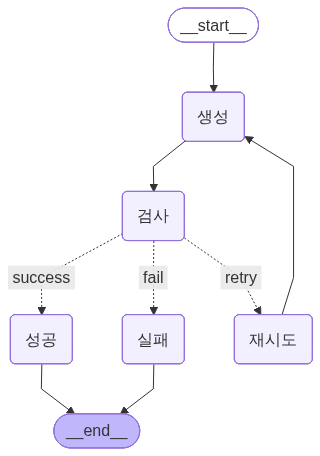

In [64]:
import os, json, re, random

from dotenv import load_dotenv
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

load_dotenv()

parser = StrOutputParser()
api_key = os.getenv("GEMINI_API_KEY")
model = "gemini-3.1-flash-lite-preview"

log.debug(f"api_key={api_key[:10]}... model={model}")

MAX_RETRY = 3

class RetryState(TypedDict):
    number: int
    retry_count: int
    status : str
    log: str

def node_generate(state: RetryState) -> dict:
    n = random.randint(1, 10)
    log.debug(f"    [생성] 난수 생성: {n}")
    return {"number": n}

def node_check(state: RetryState) -> dict:
    n = state["number"]
    if n  < 3:
        log.debug(f"    [작은수] {n} 성공")
        return {"status": "passed", "log": f"작은수 {n} 성공"}
    elif state['retry_count'] >= MAX_RETRY:
        log.debug(f"    [실패] {n} 실패, 재시도 {state['retry_count']}/{MAX_RETRY}")
        return {"status": "fail", "log": f"실패 {state['retry_count']}/{MAX_RETRY}"}
    else:
        log.debug(f"    [큰수] {n} 실패, 재시도 {state['retry_count']}/{MAX_RETRY}")
        return {"status": "retry", "log": f"큰수 {n} 실패, 재시도 {state['retry_count']}/{MAX_RETRY}"}

def node_retry(state: RetryState) -> dict:
    new_count = state["retry_count"] + 1
    log.debug(f"[재시도] 재시도 {new_count}/{MAX_RETRY}")
    return {"retry_count": new_count, "retry_count": new_count, "log": f"재시도 {new_count}/{MAX_RETRY}"}

def node_success(state: RetryState) -> dict:
    log.debug(f"    [성공] {state}")
    return {}

def node_fail(state: RetryState) -> dict:
    log.debug(f"    [실패] {state}")
    return {}

def edges_check(state: RetryState)-> str:
    log.debug(f"    [edges_check] 상태 확인: {state}")
    if state['status'] == 'passed':
        return "success"
    elif state['retry_count'] < MAX_RETRY:
        return "retry"
    else:
        return "fail"
    
s = StateGraph( RetryState)
s.add_node("생성", node_generate)
s.add_node("검사", node_check)
s.add_node("재시도", node_retry)
s.add_node("성공", node_success)
s.add_node("실패", node_fail)

s.add_edge(START, "생성")
s.add_edge("생성", "검사")
s.add_conditional_edges("검사", edges_check, {"success": "성공", "retry": "재시도", "fail": "실패"})
s.add_edge("재시도", "생성")
s.add_edge("성공", END)
s.add_edge("실패", END)

ap = s.compile()

display(Image(ap.get_graph().draw_mermaid_png()))

26-07-09 20:04:52 [D] api_key=AIzaSyDEis... model=gemini-3.1-flash-lite-preview


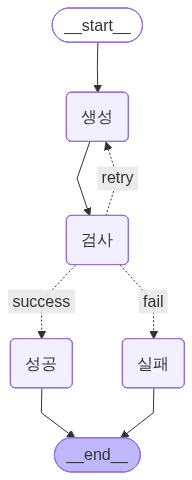

In [80]:
import os, json, re, random

from dotenv import load_dotenv
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

load_dotenv()

parser = StrOutputParser()
api_key = os.getenv("GEMINI_API_KEY")
model = "gemini-3.1-flash-lite-preview"

log.debug(f"api_key={api_key[:10]}... model={model}")

MAX_RETRY = 3

class RetryState(TypedDict):
    number: int
    retry_count: int
    status : str
    log: str

def node_generate(state: RetryState) -> dict:
    n = random.randint(1, 10)
    log.debug(f"    [생성] 난수 생성: {n}")
    new_count = state["retry_count"] + 1
    return {"number": n, "retry_count": new_count}

def node_check(state: RetryState) -> dict:
    n = state["number"]
    if n  < 3:
        log.debug(f"    [작은수] {n} 성공")
        return {"status": "passed", "log": f"작은수 {n} 성공"}
    elif state['retry_count'] >= MAX_RETRY:
        log.debug(f"    [실패] {n} 실패, 재시도 {state['retry_count']}/{MAX_RETRY}")
        return {"status": "fail", "log": f"큰수 {n} 실패 {state['retry_count']}/{MAX_RETRY}"}
    else:
        log.debug(f"    [큰수] {n} 실패, 재시도 {state['retry_count']}/{MAX_RETRY}")
        return {"status": "retry", "log": f"큰수 {n} 실패, 재시도 {state['retry_count']}/{MAX_RETRY}"}

def node_success(state: RetryState) -> dict:
    log.debug(f"    [성공] {state}")
    return {}

def node_fail(state: RetryState) -> dict:
    log.debug(f"    [실패] {state}")
    return {}

def edges_check(state: RetryState)-> str:
    log.debug(f"    [edges_check] 상태 확인: {state}")
    if state['status'] == 'passed':
        return "success"
    elif state['retry_count'] < MAX_RETRY:
        return "retry"
    else:
        return "fail"
    
s = StateGraph( RetryState)
s.add_node("생성", node_generate)
s.add_node("검사", node_check)
s.add_node("성공", node_success)
s.add_node("실패", node_fail)

s.add_edge(START, "생성")
s.add_edge("생성", "검사")
s.add_conditional_edges("검사", edges_check, {"success": "성공", "retry": "생성", "fail": "실패"})
s.add_edge("성공", END)
s.add_edge("실패", END)

ap = s.compile()

display(Image(ap.get_graph().draw_mermaid_png()))

In [83]:

result = await ap.ainvoke({"number": 0, "retry_count": 0, "status": "", "log": ""})
print_dic_tree(result)


26-07-09 20:04:59 [D]     [생성] 난수 생성: 4
26-07-09 20:04:59 [D]     [큰수] 4 실패, 재시도 1/3
26-07-09 20:04:59 [D]     [edges_check] 상태 확인: {'number': 4, 'retry_count': 1, 'status': 'retry', 'log': '큰수 4 실패, 재시도 1/3'}
26-07-09 20:04:59 [D]     [생성] 난수 생성: 8
26-07-09 20:04:59 [D]     [큰수] 8 실패, 재시도 2/3
26-07-09 20:04:59 [D]     [edges_check] 상태 확인: {'number': 8, 'retry_count': 2, 'status': 'retry', 'log': '큰수 8 실패, 재시도 2/3'}
26-07-09 20:04:59 [D]     [생성] 난수 생성: 9
26-07-09 20:04:59 [D]     [실패] 9 실패, 재시도 3/3
26-07-09 20:04:59 [D]     [edges_check] 상태 확인: {'number': 9, 'retry_count': 3, 'status': 'fail', 'log': '큰수 9 실패 3/3'}
26-07-09 20:04:59 [D]     [실패] {'number': 9, 'retry_count': 3, 'status': 'fail', 'log': '큰수 9 실패 3/3'}


├─ number [int]: 9
├─ retry_count [int]: 3
├─ status [str]: fail
├─ log [str]: 큰수 9 실패 3/3


In [98]:
# ── 이전 강의 재료: Tool 4개 ───────────────────────────────────────────────
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI

def safe_eval(expr: str) -> float:
    import re
    ALLOWED = r'^[0-9 +\-*/%().]+$'
    if not re.match(ALLOWED, expr.strip()):
        raise ValueError(f"허용되지 않는 문자: {expr}")
    return eval(expr)

@tool
def calculator_tool(expression: str) -> str:
    """
    [사용 상황] 수학 연산이 필요할 때 사용. +, -, *, /, **, //, % 연산 지원.
    [비사용 상황] 텍스트 처리, 날짜 조회, 번역에는 사용하지 말 것.
    입력: 수식 문자열 (예: '3**7 + 2**10')
    출력: 계산 결과 문자열
    """
    try:
        result = safe_eval(expression)
        if isinstance(result, float) and result.is_integer():
            return f"계산 결과: {int(result)}"
        return f"계산 결과: {result:.4f}"
    except Exception as e:
        return f"계산 오류: {e}"

@tool
def get_current_datetime(dummy: str = "") -> str:
    """
    [사용 상황] 현재 날짜와 시간을 알아야 할 때 사용.
    [비사용 상황] 계산, 번역, 보고서 작성에는 사용하지 말 것.
    입력: 없음 (빈 문자열 전달)
    출력: 현재 날짜와 시간 문자열
    """
    from datetime import datetime
    now = datetime.now()
    wd = ["월요일","화요일","수요일","목요일","금요일","토요일","일요일"]
    return now.strftime(f"%Y년 %m월 %d일 {wd[now.weekday()]} %H:%M:%S")

class TranslateInput(BaseModel):
    text: str = Field(description="번역할 원문 텍스트")
    target_lang: str = Field(description="목표 언어 코드 (예: 'ko', 'en', 'ja')")

# ★ async def: OpenAI 네트워크 I/O → AsyncOpenAI로 전환
@tool(args_schema=TranslateInput)
async def translate_tool(text: str, target_lang: str) -> str:
    """
    [사용 상황] 텍스트를 다른 언어로 번역해야 할 때 사용.
    [비사용 상황] 계산이나 정보 검색에는 사용하지 말 것.
    입력: 번역할 텍스트(text) + 목표 언어 코드(target_lang)
    출력: 번역된 텍스트 문자열
    """
    lang_names = {"ko": "한국어", "en": "영어", "ja": "일본어", "zh": "중국어", "fr": "프랑스어"}
    lang_name = lang_names.get(target_lang, target_lang)

    llm = ChatGoogleGenerativeAI(model=model, google_api_key=api_key, temperature=0)
    resp = await llm.ainvoke([SystemMessage(content="너는 전문 번역가야. 번역문만 출력하고 다른 설명은 하지 마시오."),
                            HumanMessage(content=f"다음 텍스트를 {lang_name}로 번역하시오.\n텍스트: {text}")])
    print_dic_tree(resp)
    return resp.content

class ReportInput(BaseModel):
    title: str = Field(description="보고서 제목")
    content: str = Field(description="보고서 본문 내용")

@tool(args_schema=ReportInput)
def format_report(title: str, content: str) -> str:
    """
    [사용 상황] 수집된 정보를 보고서 형식으로 정리해야 할 때 사용. 반드시 마지막 단계에서 사용.
    [비사용 상황] 정보 수집, 계산, 번역 단계에서는 사용하지 말 것.
    입력: 보고서 제목(title) + 본문 내용(content)
    출력: 형식이 갖춰진 보고서 문자열
    """
    from datetime import datetime
    sep = "=" * 50
    now = datetime.now().strftime("%Y-%m-%d %H:%M")
    return f"""{sep}
📋 {title}
{sep}
작성일시: {now}

{content}

{sep}""".strip()

tools = [calculator_tool, get_current_datetime, translate_tool, format_report]
tool_map = {t.name: t for t in tools}
print(f"✅ Tool {len(tools)}개 정의 완료: {[t.name for t in tools]}")
print("-" * 80, flush=True)

for i, t in enumerate(tools, start=1):
    print_dic_tree(t)
    schema = t.args_schema.schema() if t.args_schema else {}
    print_dic_tree(schema)


✅ Tool 4개 정의 완료: ['calculator_tool', 'get_current_datetime', 'translate_tool', 'format_report']
--------------------------------------------------------------------------------


└─ StructuredTool: name='calculator_tool' description="[사용 상황] 수학 연산이 필요할 때 사용. +, -, *, /, **, //, % 연산 지원.\n[비사용 상황] ...
├─ description [str]: [사용 상황] 수학 연산이 필요할 때 사용. +, -, *, /, **, //, % 연산 지원.
[비사용 상황] 텍스트 처리, 날짜 조회, 번역에는 사용하지 말 것.
입력: 수식 ...
├─ properties [dict]
│  ├─ expression [dict]
│  │  ├─ title [str]: Expression
│  │  ├─ type [str]: string
├─ required [list]
│  ├─ [0] [str]: expression
├─ title [str]: calculator_tool
├─ type [str]: object
└─ StructuredTool: name='get_current_datetime' description='[사용 상황] 현재 날짜와 시간을 알아야 할 때 사용.\n[비사용 상황] 계산, 번역, 보고서 작성에는 사...
├─ description [str]: [사용 상황] 현재 날짜와 시간을 알아야 할 때 사용.
[비사용 상황] 계산, 번역, 보고서 작성에는 사용하지 말 것.
입력: 없음 (빈 문자열 전달)
출력: 현재 날짜와 시간 문...
├─ properties [dict]
│  ├─ dummy [dict]
│  │  ├─ default [str]: 
│  │  ├─ title [str]: Dummy
│  │  ├─ type [str]: string
├─ title [str]: get_current_datetime
├─ type [str]: object
└─ StructuredTool: name='translate_tool' description='[사용 상황] 텍스트를 다른 언어로 번역해야 할 때 사용.\n[비사용 상황] 계산이나 정보 검색에는 사용하지 

C:\Users\dev\AppData\Local\Temp\ipykernel_22008\4132953805.py:95: PydanticDeprecatedSince20: The `schema` method is deprecated; use `model_json_schema` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  schema = t.args_schema.schema() if t.args_schema else {}


In [151]:
def build_tool_description(tools):
    """
    도구 목록을 받아서 LLM에게 제공할 도구 설명 문자열 생성
    """
    # print('=' * 80)
    lines = []
    for i, t in enumerate(tools, start=1):
        lines.append(f"{i}. [{t.name}]")
        lines.append(f"    {t.description}")
        schema = t.args_schema.schema() if t.args_schema else {}
        # print(f"schema: {schema}")
        if 'properties' in schema:
            args_info = ",".join(
                f"{k}:{v.get('description', v.get('type',''))}"
                for k, v in schema['properties'].items()
            )
            lines.append(f"    입력 인자: {args_info}")
        # print('=' * 80)
    return "\n".join(lines)

tool_descriptions_str = build_tool_description(tools)
print(f"tool_descriptions_str:\n{tool_descriptions_str}\n")



tool_descriptions_str:
1. [calculator_tool]
    [사용 상황] 수학 연산이 필요할 때 사용. +, -, *, /, **, //, % 연산 지원.
[비사용 상황] 텍스트 처리, 날짜 조회, 번역에는 사용하지 말 것.
입력: 수식 문자열 (예: '3**7 + 2**10')
출력: 계산 결과 문자열
    입력 인자: expression:string
2. [get_current_datetime]
    [사용 상황] 현재 날짜와 시간을 알아야 할 때 사용.
[비사용 상황] 계산, 번역, 보고서 작성에는 사용하지 말 것.
입력: 없음 (빈 문자열 전달)
출력: 현재 날짜와 시간 문자열
    입력 인자: dummy:string
3. [translate_tool]
    [사용 상황] 텍스트를 다른 언어로 번역해야 할 때 사용.
[비사용 상황] 계산이나 정보 검색에는 사용하지 말 것.
입력: 번역할 텍스트(text) + 목표 언어 코드(target_lang)
출력: 번역된 텍스트 문자열
    입력 인자: text:번역할 원문 텍스트,target_lang:목표 언어 코드 (예: 'ko', 'en', 'ja')
4. [format_report]
    [사용 상황] 수집된 정보를 보고서 형식으로 정리해야 할 때 사용. 반드시 마지막 단계에서 사용.
[비사용 상황] 정보 수집, 계산, 번역 단계에서는 사용하지 말 것.
입력: 보고서 제목(title) + 본문 내용(content)
출력: 형식이 갖춰진 보고서 문자열
    입력 인자: title:보고서 제목,content:보고서 본문 내용



C:\Users\dev\AppData\Local\Temp\ipykernel_22008\3843596540.py:10: PydanticDeprecatedSince20: The `schema` method is deprecated; use `model_json_schema` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  schema = t.args_schema.schema() if t.args_schema else {}


In [152]:
# ── 이전 강의 재료: Tool 4개 ───────────────────────────────────────────────
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI

def safe_eval(expr: str) -> float:
    import re
    ALLOWED = r'^[0-9 +\-*/%().]+$'
    if not re.match(ALLOWED, expr.strip()):
        raise ValueError(f"허용되지 않는 문자: {expr}")
    return eval(expr)

@tool
def calculator_tool(expression: str) -> str:
    """
    [사용 상황] 수학 연산이 필요할 때 사용. +, -, *, /, **, //, % 연산 지원.
    [비사용 상황] 텍스트 처리, 날짜 조회, 번역에는 사용하지 말 것.
    입력: 수식 문자열 (예: '3**7 + 2**10')
    출력: 계산 결과 문자열
    """
    try:
        result = safe_eval(expression)
        if isinstance(result, float) and result.is_integer():
            return f"계산 결과: {int(result)}"
        return f"계산 결과: {result:.4f}"
    except Exception as e:
        return f"계산 오류: {e}"

@tool
def get_current_datetime(dummy: str = "") -> str:
    """
    [사용 상황] 현재 날짜와 시간을 알아야 할 때 사용.
    [비사용 상황] 계산, 번역, 보고서 작성에는 사용하지 말 것.
    입력: 없음 (빈 문자열 전달)
    출력: 현재 날짜와 시간 문자열
    """
    from datetime import datetime
    now = datetime.now()
    wd = ["월요일","화요일","수요일","목요일","금요일","토요일","일요일"]
    return now.strftime(f"%Y년 %m월 %d일 {wd[now.weekday()]} %H:%M:%S")

class TranslateInput(BaseModel):
    text: str = Field(description="번역할 원문 텍스트")
    target_lang: str = Field(description="목표 언어 코드 (예: 'ko', 'en', 'ja')")

# ★ async def: OpenAI 네트워크 I/O → AsyncOpenAI로 전환
@tool(args_schema=TranslateInput)
async def translate_tool(text: str, target_lang: str) -> str:
    """
    [사용 상황] 텍스트를 다른 언어로 번역해야 할 때 사용.
    [비사용 상황] 계산이나 정보 검색에는 사용하지 말 것.
    입력: 번역할 텍스트(text) + 목표 언어 코드(target_lang)
    출력: 번역된 텍스트 문자열
    """
    lang_names = {"ko": "한국어", "en": "영어", "ja": "일본어", "zh": "중국어", "fr": "프랑스어"}
    lang_name = lang_names.get(target_lang, target_lang)
    llm = ChatGoogleGenerativeAI(model=model, google_api_key=api_key, temperature=0)
    resp = await llm.ainvoke(
        f"다음 텍스트를 {lang_name}로 번역하시오. 번역문만 출력하고 다른 설명은 하지 마시오.\n텍스트: {text}"
    )
    return resp.content

class ReportInput(BaseModel):
    title: str = Field(description="보고서 제목")
    content: str = Field(description="보고서 본문 내용")

@tool(args_schema=ReportInput)
def format_report(title: str, content: str) -> str:
    """
    [사용 상황] 수집된 정보를 보고서 형식으로 정리해야 할 때 사용. 반드시 마지막 단계에서 사용.
    [비사용 상황] 정보 수집, 계산, 번역 단계에서는 사용하지 말 것.
    입력: 보고서 제목(title) + 본문 내용(content)
    출력: 형식이 갖춰진 보고서 문자열
    """
    from datetime import datetime
    sep = "=" * 50
    now = datetime.now().strftime("%Y-%m-%d %H:%M")
    return f"""{sep}
📋 {title}
{sep}
작성일시: {now}

{content}

{sep}""".strip()

tools = [calculator_tool, get_current_datetime, translate_tool, format_report]
tool_map = {t.name: t for t in tools}
print(f"✅ Tool {len(tools)}개 정의 완료: {[t.name for t in tools]}")


# ── 이전 강의 재료: 도구 설명 문자열 + Planner/Parser/Checker Chain ─────────

def build_tool_description(tools: list) -> str:
    lines = []
    for i, t in enumerate(tools, 1):
        lines.append(f"{i}. [{t.name}]")
        lines.append(f"   {t.description}")
        schema = t.args_schema.model_json_schema() if t.args_schema else {}
        if 'properties' in schema:
            args_info = ", ".join(
                f"{k}: {v.get('description', v.get('type', ''))}"
                for k, v in schema['properties'].items()
            )
            lines.append(f"   입력 인자: {args_info}")
        lines.append("")
    return "\n".join(lines)

tool_description_str = build_tool_description(tools)

# Planner Chain
planner_prompt = PromptTemplate.from_template(
    """당신은 AI 계획 수립자입니다. 사용자의 요청을 분석하고 주어진 도구들로 실행 계획을 수립하세요.

[사용 가능한 도구 목록]
{tool_descriptions}

[사용자 요청]
{user_input}

{replan_context}

다음 JSON 형식으로만 답변하세요:
{{
  "plan": [
    {{"step": 1, "tool": "도구 이름", "purpose": "이 단계에서 수행할 작업", "input_hint": "입력값 힌트"}}
  ]
}}
"""
)
planner_chain = planner_prompt | llm | JsonOutputParser()

# Parser Chain
parser_prompt = PromptTemplate.from_template(
    """당신은 도구 입력값 추출 전문가입니다.

[사용자 원래 요청]
{user_input}

[전체 실행 계획]
{plan}

[현재 실행할 도구]
도구명: {tool_name}
입력 스키마: {tool_schema}
힌트: {input_hint}

[지금까지의 실행 결과]
{previous_results}

다음 JSON 형식으로만 답변하세요:
{{"tool_inputs": {{"인자명": "실제 값"}}}}
"""
)
parser_chain = parser_prompt | llm | JsonOutputParser()

# Checker Chain — replan 상태 추가
checker_prompt = PromptTemplate.from_template(
    """당신은 AI 실행 결과 검증자입니다.

[실행된 도구]
도구명: {tool_name}
목적: {purpose}
입력: {tool_input}
출력: {tool_output}

[이후 남은 계획]
{next_step_info}

[전체 계획 대비 현재 위치]
현재 스텝: {current_step} / 전체 {total_steps}단계

판정 기준 (반드시 아래 4가지 중 하나):
- passed: 도구 출력이 목적에 부합하고 오류가 없음
- retry : 도구 선택/순서는 맞지만 실행 결과가 기준 미달 (재실행 시 나아질 가능성)
- replan: 도구 선택이 잘못됐거나 현재 계획으로는 목표 달성 불가능. 재실행(retry)가 반복되어도 문제가 해결되지 않는 경우.
- stop  : 복구 불가능한 오류 발생

다음 JSON 형식으로만 답변하세요:
{{
  "status": "passed 또는 retry 또는 replan 또는 stop",
  "reason": "판단 근거",
  "extracted": {{"핵심정보키": "이후 단계에서 참조할 값"}}
}}
"""
)
checker_chain = checker_prompt | llm | JsonOutputParser()

print("✅ Planner / Parser / Checker Chain 정의 완료")


# ── AgentState 정의 ────────────────────────────────────────────────
from typing import TypedDict

MAX_RETRY  = 2   # 스텝당 최대 재시도 횟수
MAX_REPLAN = 2   # 최대 재계획 횟수

class AgentState(TypedDict):
    # ── 영속 데이터 (실행 내내 누적) ──────────────────────────────
    user_input: str          # 사용자 요청 원문
    plan: list               # Planner가 생성한 실행 계획
    results: dict            # 단계별 실행 결과

    # ── 실행 제어 ─────────────────────────────────────────────────
    current_step_idx: int    # 현재 실행 중인 단계 (0-based)
    retry_count: int         # 현재 단계 재시도 횟수
    retry_hint: str          # Checker가 전달하는 재시도 실패 원인
    replan_count: int        # 전체 재계획 횟수 (무한루프 방지)
    replan_reason: str       # Checker가 전달하는 재계획 사유

    # ── 임시 데이터 (단계 간 전달용) ─────────────────────────────
    current_tool_inputs: dict   # Parser → Executor
    current_tool_output: str    # Executor → Checker
    checker_status: str         # Checker → 라우터 (passed/retry/replan/stop)

print("✅ AgentState 정의 완료")
print("   필드 목록:", list(AgentState.__annotations__.keys()))

# ── 노드 1: planner_node ─────────────────────────────────────────────
async def planner_node(state: AgentState) -> dict:
    """실행 계획을 수립하고 상태를 초기화"""
    print(f"\n{'='*60}")
    if state.get("replan_count", 0) == 0:
        print(f"[사용자 요청] {state['user_input']}")
    else:
        print(f"[재계획 #{state['replan_count']}] 사유: {state.get('replan_reason', '')}")
    print(f"{'='*60}")
    print("🔵 [Planner] 실행 계획 수립 중...")

    # 재계획 시 사유를 Planner에 전달
    replan_ctx = ""
    if state.get("replan_reason"):
        replan_ctx = f"[재계획 요청] 이전 계획의 문제: {state['replan_reason']}\n새 계획 수립 시 이 점을 반드시 고려하세요."

    plan_result = await planner_chain.ainvoke({
        "tool_descriptions": tool_description_str,
        "user_input": state["user_input"],
        "replan_context": replan_ctx,
    })
    plan = plan_result.get("plan", [])

    print(f"📋 실행 계획 ({len(plan)}단계):")
    for step in plan:
        print(f"   스텝 {step['step']}: [{step['tool']}] - {step['purpose']}")

    return {
        "plan": plan,
        "current_step_idx": 0,
        "retry_count": 0,
        "retry_hint": "",
        "replan_reason": "",
        "results": {},
        "current_tool_inputs": {},
        "current_tool_output": "",
        "checker_status": "",
    }

print("✅ planner_node")

# ── 노드 2: parser_node ───────────────────────────────────────────────
async def parser_node(state: AgentState) -> dict:
    """현재 도구의 입력값을 파싱"""
    step_info   = state["plan"][state["current_step_idx"]]
    tool_name   = step_info["tool"]
    input_hint  = step_info.get("input_hint", "")
    step_num    = state["current_step_idx"] + 1
    total_steps = len(state["plan"])

    print(f"\n🔵 [스텝 {step_num}/{total_steps}] {tool_name} 실행 중...")

    current_tool = tool_map.get(tool_name)
    schema = current_tool.args_schema.model_json_schema() if (current_tool and current_tool.args_schema) else {}
    tool_schema_str = json.dumps(schema.get("properties", {}), ensure_ascii=False)

    hint = input_hint
    if state.get("retry_hint"):
        hint += f" [재시도 이유: {state['retry_hint']}]"

    print(f"   🔸 Parser Chain 실행 중...", end=" ")
    parser_result = await parser_chain.ainvoke({
        "user_input": state["user_input"],
        "plan": json.dumps(state["plan"], ensure_ascii=False),
        "tool_name": tool_name,
        "tool_schema": tool_schema_str,
        "input_hint": hint,
        "previous_results": json.dumps(state["results"], ensure_ascii=False, indent=2),
    })
    tool_inputs = parser_result.get("tool_inputs", {})
    print(f"입력값: {tool_inputs}")
    return {"current_tool_inputs": tool_inputs}

print("✅ parser_node")


# ── 노드 3: executor_node ────────────────────────────────────────────
async def executor_node(state: AgentState) -> dict:
    """도구를 실행 — translate_tool이 async이므로 await ainvoke() 필수"""
    step_info    = state["plan"][state["current_step_idx"]]
    tool_name    = step_info["tool"]
    current_tool = tool_map.get(tool_name)
    tool_inputs  = state["current_tool_inputs"]

    if current_tool is None:
        return {"current_tool_output": f"오류: 등록되지 않은 도구 '{tool_name}'"}

    schema    = current_tool.args_schema.model_json_schema() if current_tool.args_schema else {}
    first_arg = list(schema.get("properties", {}).keys())

    print(f"   🔸 [{tool_name}] 실행 중...", end=" ")
    try:
        if tool_inputs:
            tool_output = await current_tool.ainvoke(tool_inputs)
        elif first_arg:
            tool_output = await current_tool.ainvoke({first_arg[0]: ""})
        else:
            tool_output = await current_tool.ainvoke({})
    except Exception as e:
        tool_output = f"실행 오류: {e}"

    print(f"완료")
    print(f"   📤 출력: {str(tool_output)[:100]}...")
    return {"current_tool_output": str(tool_output)}

print("✅ executor_node")



# ── 노드 4: checker_node (replan 상태 추가) ──────────────────────────
async def checker_node(state: AgentState) -> dict:
    """실행 결과 검증 + 상태 업데이트"""
    step_idx    = state["current_step_idx"]
    step_info   = state["plan"][step_idx]
    step_num    = step_idx + 1
    total_steps = len(state["plan"])

    next_steps     = state["plan"][step_idx + 1:]
    next_step_info = json.dumps(next_steps, ensure_ascii=False) if next_steps else "없음 (마지막 스텝)"

    print(f"   🔸 Checker Chain 실행 중...", end=" ")
    checker_result = await checker_chain.ainvoke({
        "tool_name"    : step_info["tool"],
        "purpose"      : step_info["purpose"],
        "tool_input"   : json.dumps(state["current_tool_inputs"], ensure_ascii=False),
        "tool_output"  : state["current_tool_output"],
        "next_step_info": next_step_info,
        "current_step" : step_num,
        "total_steps"  : total_steps,
    })

    status    = checker_result.get("status", "stop")
    reason    = checker_result.get("reason", "")
    extracted = checker_result.get("extracted", {})
    print(f"상태: {status}")

    updates = {"checker_status": status}

    if status == "passed":
        new_results = dict(state["results"])
        new_results[f"step_{step_num}"] = {
            "tool": step_info["tool"],
            "input": state["current_tool_inputs"],
            "output": state["current_tool_output"],
            "extracted": extracted,
        }
        updates["results"]     = new_results
        updates["retry_count"] = 0
        updates["retry_hint"]  = ""
        print(f"   ✅ 스텝 {step_num} 완료: {reason}")

    elif status == "retry":
        updates["retry_count"] = state["retry_count"] + 1
        updates["retry_hint"]  = reason
        print(f"   🔄 재시도 {state['retry_count'] + 1}/{MAX_RETRY}: {reason}")

    elif status == "replan":
        # ★ 신규: 재계획 사유를 State에 저장
        updates["replan_reason"] = reason
        updates["replan_count"]  = state.get("replan_count", 0) + 1
        print(f"   🔁 재계획 요청 ({state.get('replan_count',0)+1}/{MAX_REPLAN}): {reason}")

    else:  # stop
        print(f"   ❌ 스텝 {step_num} 중단: {reason}")

    return updates

print("✅ checker_node (replan 상태 포함)")

# ── 노드 5: advancer_node ────────────────────────────────────────────
async def advancer_node(state: AgentState) -> dict:
    """다음 스텝으로 전환 — LLM 호출 없음, 그래프 일관성을 위해 async def 선언"""
    return {
        "current_step_idx"   : state["current_step_idx"] + 1,
        "retry_count"        : 0,
        "retry_hint"         : "",
        "current_tool_inputs": {},
        "current_tool_output": "",
        "checker_status"     : "",
    }

# ── 노드 6: replanner_node (신규) ────────────────────────────────────
async def replanner_node(state: AgentState) -> dict:
    """
    Checker가 'replan' 판정 시 호출.
    replan_reason을 참고하여 Planner를 재호출, 새 계획을 수립하고
    current_step_idx를 0으로 초기화하여 처음부터 다시 시작한다.
    """
    print(f"\n🔁 [Replanner] 재계획 수립 중...")
    print(f"   사유: {state.get('replan_reason', '')}")

    replan_ctx = (
        f"[재계획 요청] 이전 계획의 문제점: {state.get('replan_reason', '')}\n"
        f"이전 계획: {json.dumps(state['plan'], ensure_ascii=False)}\n"
        f"위 문제점을 해결하는 새 계획을 수립하세요."
    )

    plan_result = await planner_chain.ainvoke({
        "tool_descriptions": tool_description_str,
        "user_input": state["user_input"],
        "replan_context": replan_ctx,
    })
    new_plan = plan_result.get("plan", [])

    print(f"   새 계획 ({len(new_plan)}단계):")
    for step in new_plan:
        print(f"     스텝 {step['step']}: [{step['tool']}] - {step['purpose']}")

    return {
        "plan"              : new_plan,
        "current_step_idx"  : 0,       # ← 처음부터 다시 시작
        "retry_count"       : 0,
        "retry_hint"        : "",
        "replan_reason"     : "",
        "results"           : {},      # ← 이전 결과 초기화
        "current_tool_inputs": {},
        "current_tool_output": "",
        "checker_status"    : "",
    }

print("✅ advancer_node")
print("✅ replanner_node (신규)")

# ★ 라우터 1: checker 이후 4방향 분기
def route_after_checker(state: AgentState) -> str:
    status      = state["checker_status"]
    retry_count = state["retry_count"]

    if status == "passed":
        return "advance"                              # → advancer_node
    elif status == "retry" and retry_count <= MAX_RETRY:
        return "retry"                                # → parser_node (재시도)
    elif status == "replan" and state.get("replan_count", 0) <= MAX_REPLAN:
        return "replan"                               # → replanner_node
    else:
        return "end"                                  # → END (횟수 초과 or stop)

# ★ 라우터 2: advancer 이후 — 남은 스텝 확인
def route_after_advancer(state: AgentState) -> str:
    if state["current_step_idx"] < len(state["plan"]):
        return "continue"                             # → parser_node (다음 스텝)
    else:
        return "end"                                  # → END (모든 스텝 완료)

# ★ 라우터 3: replanner 이후 — 재계획 후 처음부터
def route_after_replanner(state: AgentState) -> str:
    if state.get("replan_count", 0) <= MAX_REPLAN:
        return "continue"                             # → parser_node (새 계획 실행)
    else:
        return "stop"                                 # → END (재계획 횟수 초과)

print("✅ 라우터 함수 3개 정의 완료")
print("   route_after_checker : passed→advance | retry→retry | replan→replan | 초과→end")
print("   route_after_advancer: 스텝 남음→continue | 완료→end")
print("   route_after_replanner: 계속→continue | 초과→stop")




✅ Tool 4개 정의 완료: ['calculator_tool', 'get_current_datetime', 'translate_tool', 'format_report']
✅ Planner / Parser / Checker Chain 정의 완료
✅ AgentState 정의 완료
   필드 목록: ['user_input', 'plan', 'results', 'current_step_idx', 'retry_count', 'retry_hint', 'replan_count', 'replan_reason', 'current_tool_inputs', 'current_tool_output', 'checker_status']
✅ planner_node
✅ parser_node
✅ executor_node
✅ checker_node (replan 상태 포함)
✅ advancer_node
✅ replanner_node (신규)
✅ 라우터 함수 3개 정의 완료
   route_after_checker : passed→advance | retry→retry | replan→replan | 초과→end
   route_after_advancer: 스텝 남음→continue | 완료→end
   route_after_replanner: 계속→continue | 초과→stop


In [153]:
def create_initial_state(user_input: str) -> AgentState:
    """
    AgentState의 기본값을 생성하는 헬퍼 함수
    사용: initial_state = create_initial_state(TASK)
    """
    return {
        "user_input"          : user_input,
        "plan"                : [],
        "results"             : {},
        "current_step_idx"    : 0,
        "retry_count"         : 0,
        "retry_hint"          : "",
        "replan_count"        : 0,
        "replan_reason"       : "",
        "current_tool_inputs" : {},
        "current_tool_output" : "",
        "checker_status"      : "",
    }

print("✅ create_initial_state() 함수 정의 완료")

✅ create_initial_state() 함수 정의 완료


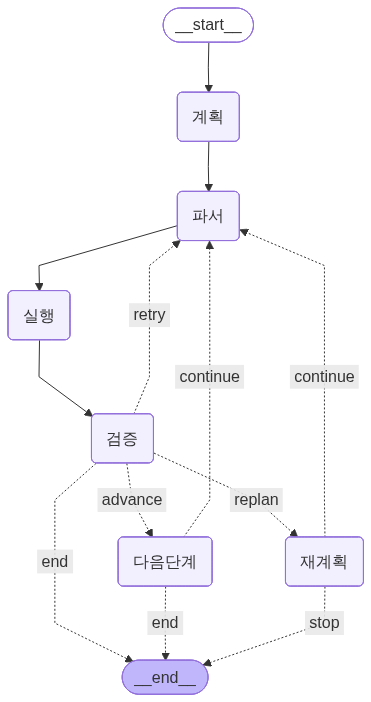

In [154]:
from langgraph.graph import END as LG_END
from langgraph.graph import StateGraph, START, END

s = StateGraph(AgentState)

s.add_node("계획", planner_node)
s.add_node("파서", parser_node)
s.add_node("실행", executor_node)
s.add_node("검증", checker_node)
s.add_node("다음단계", advancer_node)
s.add_node("재계획", replanner_node)


s.add_edge(START, "계획")
s.add_edge("계획", "파서")
s.add_edge("파서", "실행")
s.add_edge("실행", "검증")

s.add_conditional_edges(
    "검증", route_after_checker, 
    {
        "advance": "다음단계",
        "retry": "파서",
        "replan": "재계획",
        "end": END,
    }
)

s.add_conditional_edges(
    "다음단계", route_after_advancer,
    {
        "continue": "파서",
        "end": END,
    }
)

s.add_conditional_edges(
    "재계획", route_after_replanner,
    {
        "continue": "파서",
        "stop": END,
    }
)

ap = s.compile()
display(Image(ap.get_graph().draw_mermaid_png()))


In [155]:
# ── 기본 태스크 실행 (이전 강의과 동일) ────────────────────────────────────
TASK = (
    "현재 날짜와 시간을 확인하고, 3의 7제곱에 2의 10제곱을 더한 값을 계산하여 "
    "결과를 영어로 번역한 뒤, '계산 결과 보고서'라는 제목으로 보고서를 작성해줘"
)

# ★ 변경: 기본값 생성 함수 사용
initial_state = create_initial_state(TASK)

final_state = await ap.ainvoke(initial_state)

total = len(final_state["plan"])
print(f"\n{'='*60}")
print("✅ Agent 실행 완료")
print(f"{'='*60}")
print(f"   재계획 횟수: {final_state.get('replan_count', 0)}회")
last_key = f"step_{total}"
if last_key in final_state["results"]:
    print("\n=== 최종 결과 ===")
    print(final_state["results"][last_key]["output"])


[사용자 요청] 현재 날짜와 시간을 확인하고, 3의 7제곱에 2의 10제곱을 더한 값을 계산하여 결과를 영어로 번역한 뒤, '계산 결과 보고서'라는 제목으로 보고서를 작성해줘
🔵 [Planner] 실행 계획 수립 중...
📋 실행 계획 (4단계):
   스텝 1: [get_current_datetime] - 현재 날짜와 시간을 확인합니다.
   스텝 2: [calculator_tool] - 3의 7제곱에 2의 10제곱을 더한 값을 계산합니다.
   스텝 3: [translate_tool] - 계산된 결과값을 영어로 번역합니다.
   스텝 4: [format_report] - 확인된 날짜와 번역된 계산 결과를 포함하여 보고서를 작성합니다.

🔵 [스텝 1/4] get_current_datetime 실행 중...
   🔸 Parser Chain 실행 중... 입력값: {'dummy': ''}
   🔸 [get_current_datetime] 실행 중... 완료
   📤 출력: 2026년 07월 09일 목요일 21:38:24...
   🔸 Checker Chain 실행 중... 상태: passed
   ✅ 스텝 1 완료: 현재 날짜와 시간을 성공적으로 확인하였으며, 다음 단계인 계산 및 보고서 작성을 위한 정보가 확보되었습니다.

🔵 [스텝 2/4] calculator_tool 실행 중...
   🔸 Parser Chain 실행 중... 입력값: {'expression': '3**7 + 2**10'}
   🔸 [calculator_tool] 실행 중... 완료
   📤 출력: 계산 결과: 3211.0000...
   🔸 Checker Chain 실행 중... 상태: passed
   ✅ 스텝 2 완료: 3의 7제곱(2187)과 2의 10제곱(1024)의 합인 3211이 정확하게 계산되었습니다.

🔵 [스텝 3/4] translate_tool 실행 중...
   🔸 Parser Chain 실행 중... 입력값: {'text': '3211', 'target_lang'